In [14]:
import duckdb
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import joblib
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score,
                             accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, recall_score)

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [18]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

try:
    test_model = xgb.XGBClassifier(device="cuda")
    print("CUDA available — training will use GPU")
except Exception as e:
    print("CUDA not available — will fall back to CPU")
    print("Reason:", e)

param = xgb.DMatrix([[1,2],[3,4]], label=[0,1])
print("\nCUDA build info:")
print(xgb.build_info())

XGBoost version: 3.2.0
CUDA available — training will use GPU

CUDA build info:
{'BUILTIN_PREFETCH_PRESENT': False, 'CUDA_VERSION': [12, 9], 'DEBUG': False, 'MM_PREFETCH_PRESENT': True, 'THRUST_VERSION': [2, 8, 2], 'USE_CUDA': True, 'USE_DLOPEN_NCCL': False, 'USE_FEDERATED': False, 'USE_NCCL': False, 'USE_NVCOMP': False, 'USE_OPENMP': True, 'USE_RMM': False, 'libxgboost': 'D:\\Priyansh\\Projects\\Kenexai-Hackathon\\venv\\Lib\\site-packages\\xgboost\\lib\\xgboost.dll'}


In [3]:
con = duckdb.connect("../insurance.db")
df  = con.execute("SELECT * FROM gold_claims").fetchdf()

print("Shape:", df.shape)
print("\nOutcome distribution:")
print(df["OUTCOME"].value_counts())
print(f"\nClass imbalance ratio: {(df['OUTCOME']==0).sum() / (df['OUTCOME']==1).sum():.2f}")

Shape: (8149, 22)

Outcome distribution:
OUTCOME
0.0    5613
1.0    2536
Name: count, dtype: int64

Class imbalance ratio: 2.21


In [4]:
FEATURES = [
    "AGE", "GENDER", "DRIVING_EXPERIENCE", "EDUCATION",
    "INCOME", "CREDIT_SCORE", "VEHICLE_OWNERSHIP", "VEHICLE_YEAR",
    "MARRIED", "CHILDREN", "ANNUAL_MILEAGE", "VEHICLE_TYPE",
    "SPEEDING_VIOLATIONS", "DUIS", "PAST_ACCIDENTS",
    "risk_score", "high_mileage_flag"
]
TARGET = "OUTCOME"

X = df[FEATURES]
y = df[TARGET].astype(int)

# Scale pos weight handles class imbalance natively
neg = (y == 0).sum()
pos = (y == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}  (neg={neg}, pos={pos})")

scale_pos_weight: 2.21  (neg=5613, pos=2536)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (6519, 17)
Test size:  (1630, 17)


In [7]:
model = xgb.XGBClassifier(
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = scale_pos_weight,
    eval_metric           = "auc",
    early_stopping_rounds = 20,
    random_state          = 42,
    device                = "cuda"
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\nTraining complete on GPU")

[0]	validation_0-auc:0.87881
[50]	validation_0-auc:0.89152
[100]	validation_0-auc:0.89211
[102]	validation_0-auc:0.89230

Training complete on GPU


In [10]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print("\n", classification_report(y_test, y_pred))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"\nBusiness Impact Summary:")
print(f"   Correctly identified claims    : {tp} (True Positives)")
print(f"   Missed claims (costly)         : {fn} (False Negatives)")
print(f"   Unnecessary flags              : {fp} (False Positives)")
print(f"   Correctly cleared drivers      : {tn} (True Negatives)")
print(f"\n   Claim Detection Rate           : {tp/(tp+fn)*100:.1f}%")
print(f"   False Alert Rate               : {fp/(fp+tn)*100:.1f}%")

Accuracy : 0.8184
ROC-AUC  : 0.8926

               precision    recall  f1-score   support

           0       0.91      0.82      0.86      1123
           1       0.67      0.82      0.74       507

    accuracy                           0.82      1630
   macro avg       0.79      0.82      0.80      1630
weighted avg       0.84      0.82      0.82      1630


Business Impact Summary:
   Correctly identified claims    : 417 (True Positives)
   Missed claims (costly)         : 90 (False Negatives)
   Unnecessary flags              : 206 (False Positives)
   Correctly cleared drivers      : 917 (True Negatives)

   Claim Detection Rate           : 82.2%
   False Alert Rate               : 18.3%


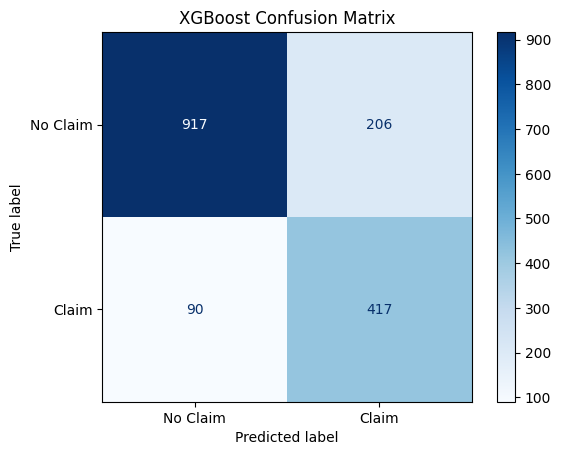

In [11]:
cm  = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=["No Claim","Claim"])
cmd.plot(cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.show()

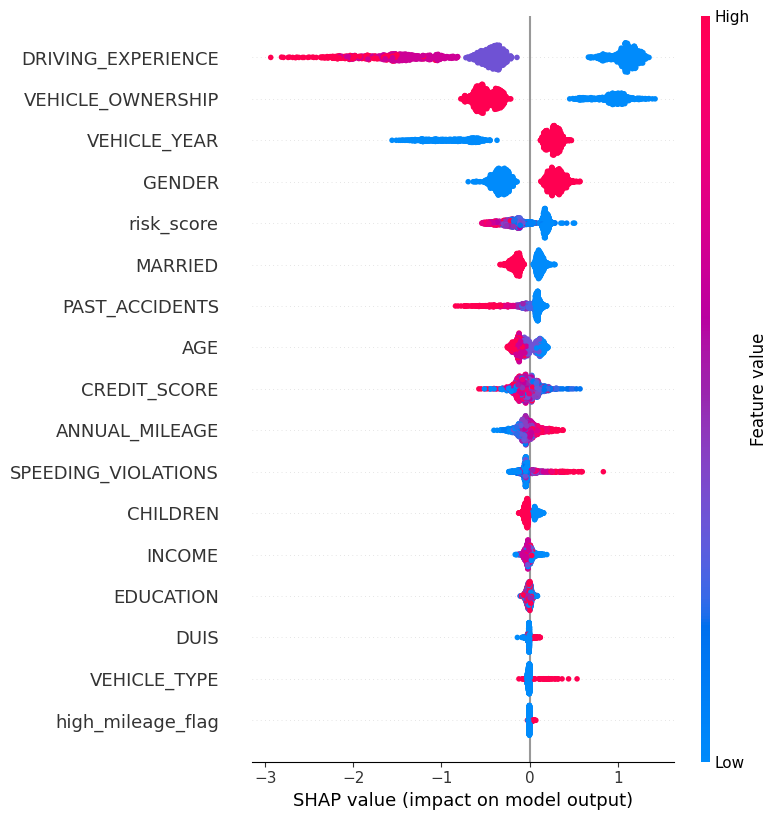

In [12]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=FEATURES)

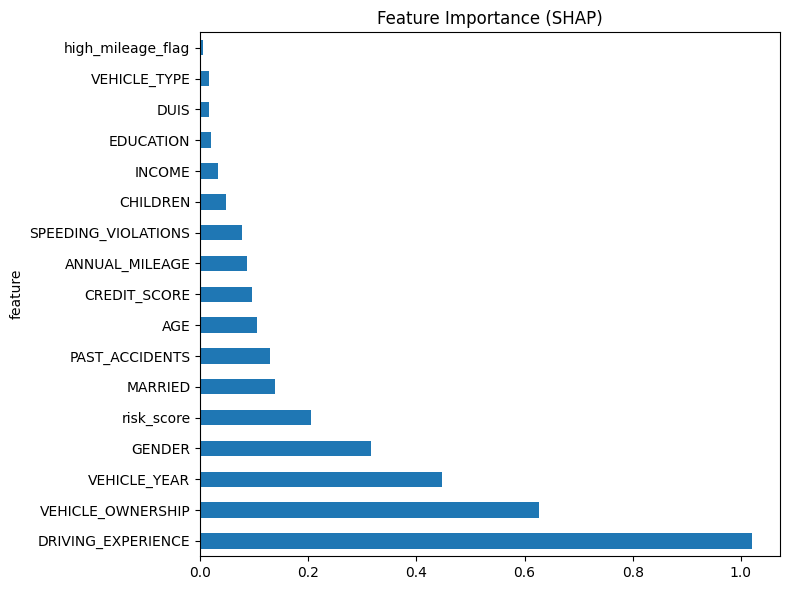

                feature  importance
2    DRIVING_EXPERIENCE    1.021353
6     VEHICLE_OWNERSHIP    0.627071
7          VEHICLE_YEAR    0.448078
1                GENDER    0.315577
15           risk_score    0.204875
8               MARRIED    0.137964
14       PAST_ACCIDENTS    0.129187
0                   AGE    0.105650
5          CREDIT_SCORE    0.095475
10       ANNUAL_MILEAGE    0.086920
12  SPEEDING_VIOLATIONS    0.077900
9              CHILDREN    0.048185
4                INCOME    0.032351
3             EDUCATION    0.020640
13                 DUIS    0.017077
11         VEHICLE_TYPE    0.016274
16    high_mileage_flag    0.006039


In [13]:
feature_importance = pd.DataFrame({
    "feature":    FEATURES,
    "importance": np.abs(shap_values).mean(axis=0)
}).sort_values("importance", ascending=False)

feature_importance.plot(
    kind="barh", x="feature", y="importance",
    figsize=(8,6), title="Feature Importance (SHAP)", legend=False
)
plt.tight_layout()
plt.show()

print(feature_importance)

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import time

# ── Train Random Forest ──
print("Training Random Forest on CPU...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators  = 500,
    max_depth     = 10,
    class_weight  = "balanced", 
    random_state  = 42,
    n_jobs        = -1      
)
rf_model.fit(X_train, y_train)
rf_time = time.time() - start

# ── Evaluate RF ──
rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_acc   = accuracy_score(y_test, rf_pred)
rf_auc   = roc_auc_score(y_test, rf_proba)

print(f"RF Training time : {rf_time:.2f}s")
print(f"   Accuracy         : {rf_acc:.4f}")
print(f"   ROC-AUC          : {rf_auc:.4f}")
print("\n", classification_report(y_test, rf_pred))

# ── Side by side comparison ──
print("\n" + "="*45)
print(f"{'Metric':<25} {'XGBoost':>8} {'RF':>8}")
print("="*45)
print(f"{'Accuracy':<25} {0.8184:>8.4f} {rf_acc:>8.4f}")
print(f"{'ROC-AUC':<25} {0.8926:>8.4f} {rf_auc:>8.4f}")
print(f"{'Recall (Claim class)':<25} {0.82:>8.2f} {recall_score(y_test, rf_pred, pos_label=1):>8.2f}")
print(f"{'Training time':<25} {'~2s GPU':>8} {rf_time:>7.1f}s")
print("="*45)

Training Random Forest on CPU...
RF Training time : 2.96s
   Accuracy         : 0.8233
   ROC-AUC          : 0.8887

               precision    recall  f1-score   support

           0       0.90      0.83      0.87      1123
           1       0.68      0.80      0.74       507

    accuracy                           0.82      1630
   macro avg       0.79      0.82      0.80      1630
weighted avg       0.83      0.82      0.83      1630


Metric                     XGBoost       RF
Accuracy                    0.8184   0.8233
ROC-AUC                     0.8926   0.8887
Recall (Claim class)          0.82     0.80
Training time              ~2s GPU     3.0s


In [17]:
joblib.dump(model, "../models/claim_model.pkl")
joblib.dump(explainer, "../models/shap_explainer.pkl")

feature_importance.to_csv("../models/feature_importance.csv", index=False)

metrics = {"accuracy": round(acc, 4), "roc_auc": round(auc, 4)}
with open("../models/metrics.json", "w") as f:
    json.dump(metrics, f)

with open("../models/feature_list.json", "w") as f:
    json.dump(FEATURES, f)

print("Model, explainer, metrics saved to models/")

Model, explainer, metrics saved to models/
